In [1]:
# 1. Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (
	r2_score as R2Score,
	mean_absolute_error as MAE,
	root_mean_squared_error as RMSE,
	mean_absolute_percentage_error as MAPE
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler

In [2]:
# 2. Load Dataset
dat = pd.read_csv('../Data/AirPassengers.csv', usecols=[1])
dat.head()

,#Passengers
0,112
1,118
2,132
3,129
4,121


In [3]:
dat.shape

(144, 1)

In [4]:
dat.isna().sum() # check for null values

#Passengers    0
dtype: int64

In [5]:
# 3. Scale the feature column (#Passengers) for feeding it into the RNN
scaler = MinMaxScaler(feature_range=(0, 1)) # Normalize (0,1)
dat = scaler.fit_transform(dat)

In [6]:
# 4. Train-test split
train_size = int(len(dat) * 0.67)
train, test = dat[0:train_size, :], dat[train_size:, :]

# Helper function for supervised dataset
def create_dataset(dataset, look_back):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

look_back = 24  # past 24 months - next month
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input [samples, timesteps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [7]:
# 5. Hybrid RNN + LSTM Model
model = Sequential([
	Input(shape=(look_back,1)),
    SimpleRNN(128, return_sequences=True, activation='tanh'),
    Dropout(0.15),
    LSTM(64, activation='tanh'),
    Dropout(0.15),
    Dense(32, activation='tanh'),
    Dropout(0.15),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 128)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,161 (266.25 KB)

 Trainable params: 68,161 (266.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 6. Callbacks
early_stop = EarlyStopping(
    monitor='val_r2_score',
	patience=200,
	restore_best_weights=True,
	verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
	factor=0.5,
	patience=15,
	min_lr=1e-4,
	verbose=1
)

In [9]:
# 7. Train
history = model.fit(
    trainX, trainY,
    epochs=200,
    batch_size=16,
    validation_data=(testX, testY),
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0785 - mae: 0.2295 - r2_score: -5.0312 - val_loss: 0.1821 - val_mae: 0.4021 - val_r2_score: -7.7604 - learning_rate: 0.0010
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0200 - mae: 0.1082 - r2_score: -0.3474 - val_loss: 0.0103 - val_mae: 0.0862 - val_r2_score: 0.5029 - learning_rate: 0.0010
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0078 - mae: 0.0743 - r2_score: 0.3951 - val_loss: 0.0505 - val_mae: 0.2142 - val_r2_score: -1.4292 - learning_rate: 0.0010
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0080 - mae: 0.0766 - r2_score: 0.3751 - val_loss: 0.0051 - val_mae: 0.0515 - val_r2_score: 0.7531 - learning_rate: 0.0010
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0051 - mae: 0.0512 - r2_score: 0.6299 - val_loss: 0.0292 - val_mae: 0.1566 - val_r2_score: -0.4061 - learning_rate: 0.0010
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0059 - mae: 0.0582 - r2_

In [10]:
# 8a. Predictions
train_pred = model.predict(trainX)
test_pred = model.predict(testX)

# invert scaling
train_pred = scaler.inverse_transform(train_pred)
trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
test_pred = scaler.inverse_transform(test_pred)
testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [ ]:
# 8b. Evaluation
train_rmse = RMSE(trainY_inv, train_pred)
test_rmse = RMSE(testY_inv, test_pred)

train_mae = MAE(trainY_inv, train_pred)
test_mae = MAE(testY_inv, test_pred)

train_mape = MAPE(trainY_inv, train_pred)
test_mape = MAPE(testY_inv, test_pred)

train_r2 = R2Score(trainY_inv, train_pred)
test_r2  = R2Score(testY_inv, test_pred)

print(f'''Training:
	- RMSE: {train_rmse:.3f}
	- MAE: {train_mae:.3f}
	- MAPE: {train_mape:.3f}%
	- R2-Score: {train_r2*100:.3f}%''')

print(f'''Testing:
	- RMSE: {test_rmse:.3f}
	- MAE: {test_mae:.3f}
	- MAPE: {test_mape:.3f}%
	- R2-Score: {test_r2*100:.3f}%''')

Training:
	- RMSE: 9.663
	- MAE: 7.170
	- MAPE: 0.031%
	- R2-Score: 97.570%
Testing:
	- RMSE: 13.540
	- MAE: 10.969
	- MAPE: 0.024%
	- R2-Score: 96.712%


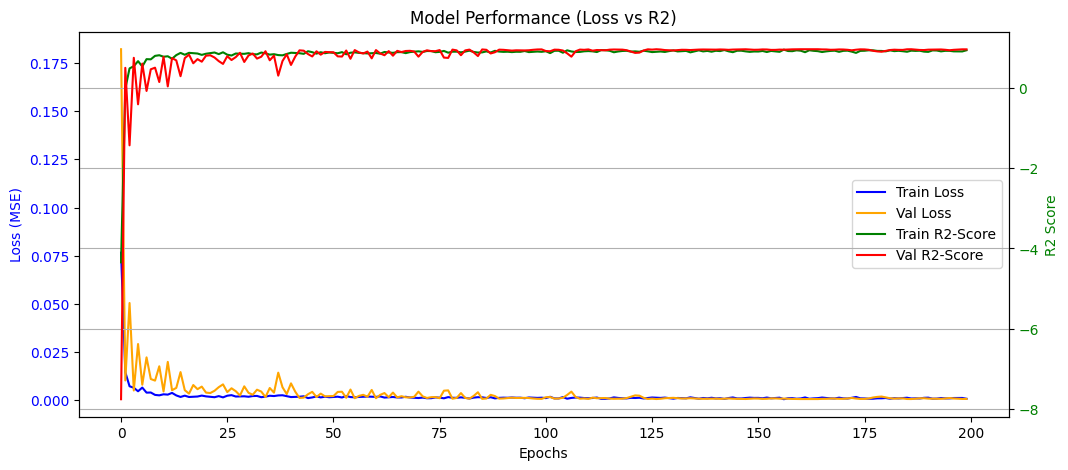

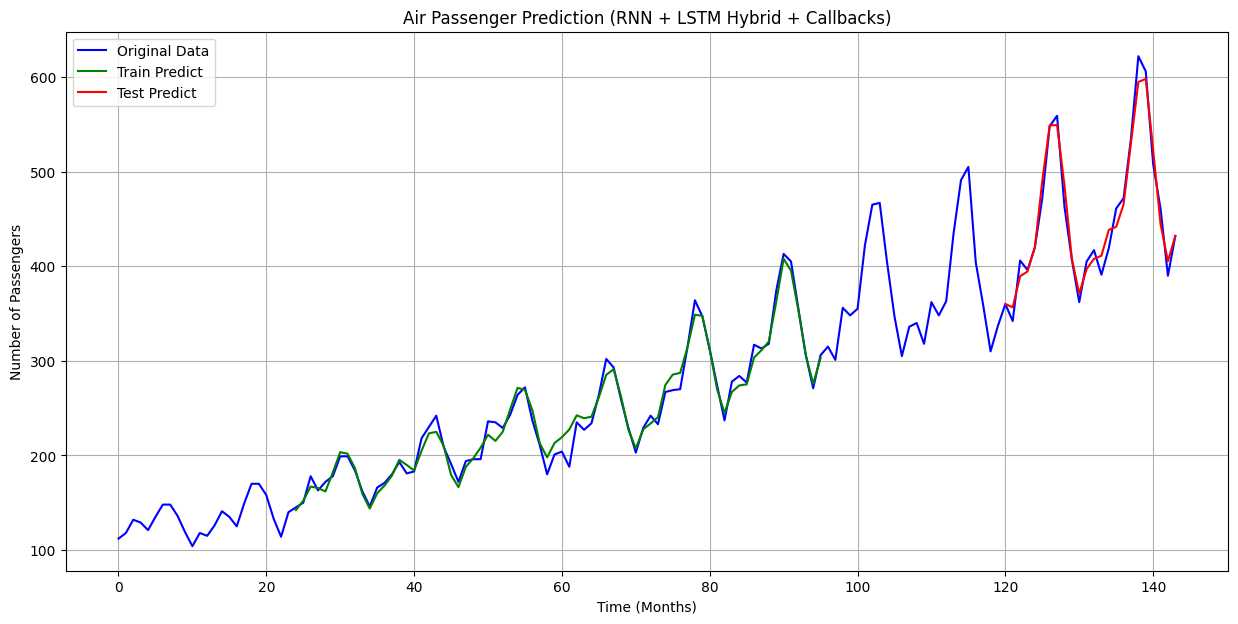

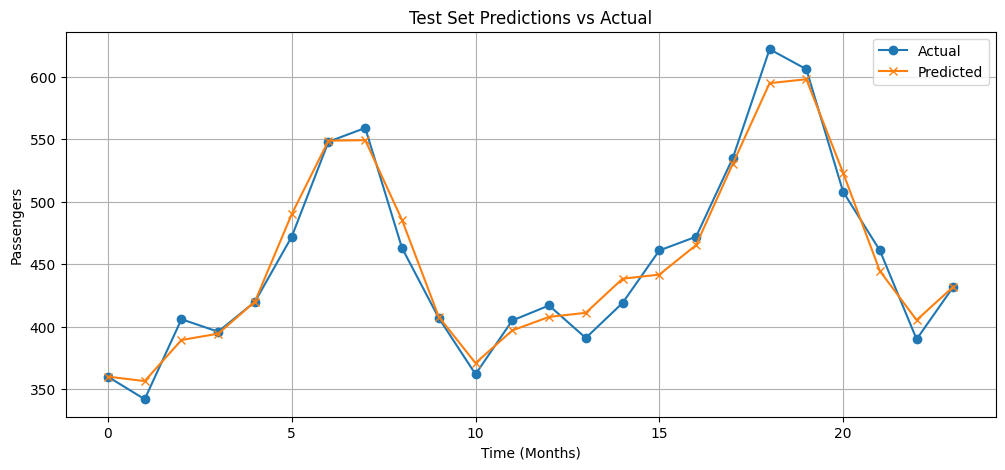

In [12]:
# 9. Visualization

fig, ax1 = plt.subplots(figsize=(12, 5))
# Left Y-axis - Loss
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
# Right Y-axis - R² Score
ax2 = ax1.twinx()
ax2.plot(history.history['r2_score'], label='Train R2-Score', color='green')
ax2.plot(history.history['val_r2_score'], label='Val R2-Score', color='red')
ax2.set_ylabel('R2 Score', color='green')
ax2.tick_params(axis='y', labelcolor='green')
# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
plt.title('Model Performance (Loss vs R2)')
plt.grid(True)
plt.show()

# Predictions vs Actual
plt.figure(figsize=(15, 7))
plt.plot(scaler.inverse_transform(dat), label='Original Data', color='blue')
plt.plot(range(look_back, look_back + len(train_pred)), train_pred, label='Train Predict', color='green')
plt.plot(range(len(dat) - len(test_pred), len(dat)), test_pred, label='Test Predict', color='red')
plt.title('Air Passenger Prediction (RNN + LSTM Hybrid + Callbacks)')
plt.xlabel('Time (Months)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# Test Set Comparison
plt.figure(figsize=(12, 5))
plt.plot(testY_inv, label='Actual', marker='o')
plt.plot(test_pred, label='Predicted', marker='x')
plt.title('Test Set Predictions vs Actual')
plt.xlabel('Time (Months)')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# 10. Save for later use
model.export('model')
model.save('model.keras')

INFO:tensorflow:Assets written to: model\assets


INFO:tensorflow:Assets written to: model\assets


Saved artifact at 'model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1743597787024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597788944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597788752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597789136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597790288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597789520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597788368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597788176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597789904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1743597790864: TensorSpec(shape=(), dtype=tf.resource, name=None)
